In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import (SimpleExpSmoothing,Holt,ExponentialSmoothing)

from sklearn.metrics import mean_absolute_error,mean_squared_error

In [3]:
data = {
    'Date':pd.date_range('2025-01-01',periods=36,freq='ME'),
    'Sales':[
        100,110,120,130,140,150,
        160,170,180,170,160,150,

        120,130,140,150,160,170,
        180,190,200,190,180,170,

        140,150,160,170,180,190,
        200,210,220,210,200,190
    ]
}

df = pd.DataFrame(data)
df.set_index(df['Date'], inplace=True)

df.head()

,Date,Sales
Date,,
2025-01-31,2025-01-31,100
2025-02-28,2025-02-28,110
2025-03-31,2025-03-31,120
2025-04-30,2025-04-30,130
2025-05-31,2025-05-31,140


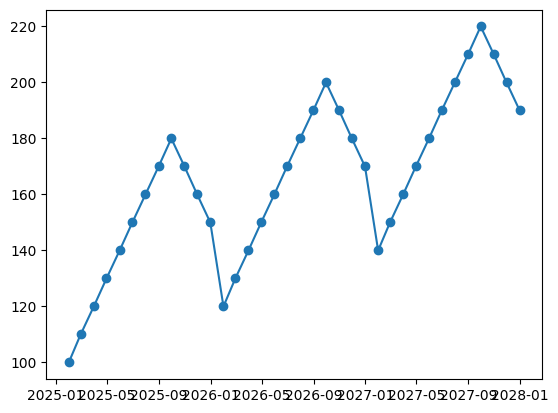

In [4]:
plt.plot(df['Sales'],marker='o')
plt.show()

In [5]:
train = df.iloc[:30]

test = df.iloc[30:]

print(train.shape)

print(test.shape)

(30, 2)
(6, 2)


### PART 1 : Simple Exponential Smoothing (SES)

In [6]:
model = SimpleExpSmoothing(train['Sales'])
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [7]:
forecast = model_fit.forecast(steps=(len(test)))
print(forecast)

2027-07-31    190.0
2027-08-31    190.0
2027-09-30    190.0
2027-10-31    190.0
2027-11-30    190.0
2027-12-31    190.0
Freq: ME, dtype: float64


In [9]:
mae = mean_absolute_error(test['Sales'],forecast)
print(mae)

15.000000149011612


In [10]:
rmse = np.sqrt(mean_squared_error(test['Sales'],forecast))
print(rmse)

17.795130545658132


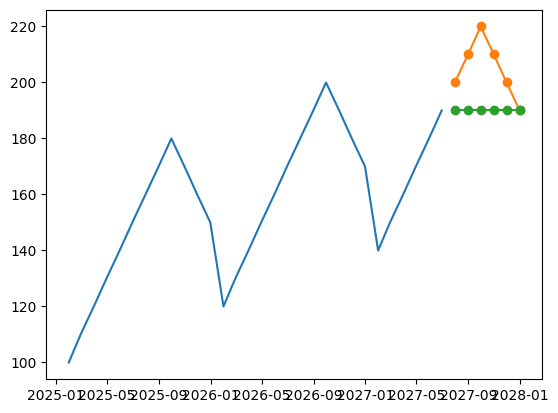

In [11]:
plt.plot(train.index, train["Sales"], label="Train")

plt.plot(test.index, test["Sales"], marker="o", label="Actual")

plt.plot(test.index, forecast, marker="o", label="Forecast")

plt.show()

### Part 2 Holt's Method (Double Exponential Smoothing)

In [12]:
model = Holt(train['Sales'])

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [13]:
model_fit = model.fit()

In [15]:
forecast = model_fit.forecast(steps=len(test))

print(forecast)

2027-07-31    199.685270
2027-08-31    209.370540
2027-09-30    219.055809
2027-10-31    228.741079
2027-11-30    238.426349
2027-12-31    248.111619
Freq: ME, dtype: float64


In [17]:
mae = mean_absolute_error(test['Sales'],forecast)

rmse = np.sqrt(mean_squared_error(test['Sales'],forecast))

print(mae)
print(rmse)

19.527904674523906
29.45663291051958


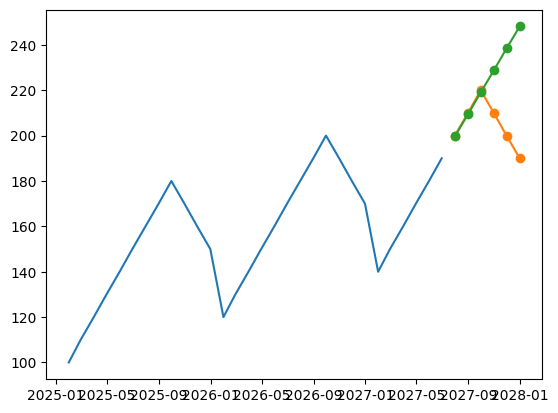

In [18]:
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], marker='o', label='Actual')
plt.plot(test.index, forecast, marker='o', label='Forecast')
plt.show()

### PART 3 : Holt-Winters (Triple Exponential Smoothing)


In [19]:
model = ExponentialSmoothing(
    train['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [20]:
model_fit = model.fit()

In [21]:
forecast = model_fit.forecast(steps=len(test))
print(forecast)

2027-07-31    199.999990
2027-08-31    209.999991
2027-09-30    219.999997
2027-10-31    209.999997
2027-11-30    199.999990
2027-12-31    189.999989
Freq: ME, dtype: float64


In [22]:
mae = mean_absolute_error(test["Sales"], forecast)

rmse = np.sqrt(mean_squared_error(test["Sales"], forecast))

print("MAE :", mae)

print("RMSE :", rmse)

MAE : 7.641863717822162e-06
RMSE : 8.277166293461371e-06


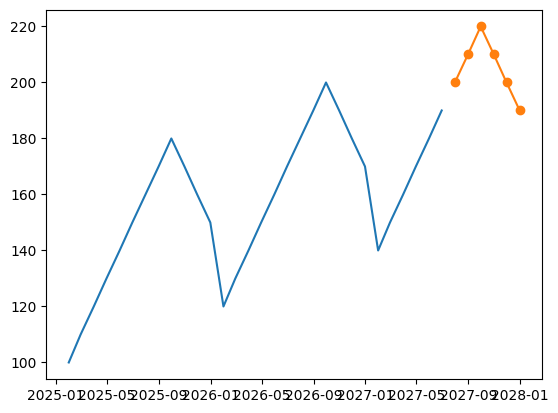

In [25]:
plt.plot(train.index, train["Sales"], label="Train")

# plt.plot(test.index, test["Sales"], marker="o", label="Actual")

plt.plot(test.index, forecast, marker="o", label="Forecast")

plt.show()

In [24]:
comparison = pd.DataFrame({
    "Actual": test["Sales"],
    "Forecast": forecast
})

print(comparison)

            Actual    Forecast
2027-07-31     200  199.999990
2027-08-31     210  209.999991
2027-09-30     220  219.999997
2027-10-31     210  209.999997
2027-11-30     200  199.999990
2027-12-31     190  189.999989
